In [1]:
# ── imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# makes charts look clean
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# ── load data ─────────────────────────────────────────────
# UCI German Credit dataset (Statlog version - already numeric)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data-numeric"

df = pd.read_csv(url, sep="\s+", header=None)

# the last column (column 24) is our target: 1 = good, 2 = bad
# converting it to 0 = good (no default), 1 = bad (default)
df.rename(columns={24: "default"}, inplace=True)
df["default"] = df["default"].map({1: 0, 2: 1})

print(f"Dataset shape: {df.shape}")
print(f"\nDefault rate: {df['default'].mean():.1%}")
print(f"Good borrowers: {(df['default']==0).sum()}")
print(f"Bad borrowers (defaults): {(df['default']==1).sum()}")

Dataset shape: (1000, 25)

Default rate: 30.0%
Good borrowers: 700
Bad borrowers (defaults): 300


In [3]:
col_names = [
    "checking_status",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_status",
    "employment",
    "installment_rate",
    "personal_status",
    "other_parties",
    "residence_since",
    "property_magnitude",
    "age",
    "other_payment_plans",
    "housing",
    "existing_credits",
    "job",
    "num_dependents",
    "own_telephone",
    "foreign_worker",
    "feat_21",
    "feat_22",
    "feat_23",
    "feat_24",
    "default"
]

print(f"Columns in df: {len(df.columns)}, names we have: {len(col_names)}")

df.columns = col_names
print("\nColumns renamed successfully")
df.head()

Columns in df: 25, names we have: 25

Columns renamed successfully


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,feat_21,feat_22,feat_23,feat_24,default
0,1,6,4,12,5,5,3,4,1,67,3,2,1,2,1,0,0,1,0,0,1,0,0,1,0
1,2,48,2,60,1,3,2,2,1,22,3,1,1,1,1,0,0,1,0,0,1,0,0,1,1
2,4,12,4,21,1,4,3,3,1,49,3,1,2,1,1,0,0,1,0,0,1,0,1,0,0
3,1,42,2,79,1,4,3,4,2,45,3,1,2,1,1,0,0,0,0,0,0,0,0,1,0
4,1,24,3,49,1,3,3,4,4,53,3,2,2,1,1,1,0,1,0,0,0,0,0,1,1


In [4]:
print("Data types")
print(df.dtypes)

print("\nAny missing values?")
print(df.isnull().sum().sum(), "missing values")  # should be 0

print("\nKey columns at a glance")
print(df[["age", "credit_amount", "duration", "default"]].describe().round(2))

Data types
checking_status        int64
duration               int64
credit_history         int64
purpose                int64
credit_amount          int64
savings_status         int64
employment             int64
installment_rate       int64
personal_status        int64
other_parties          int64
residence_since        int64
property_magnitude     int64
age                    int64
other_payment_plans    int64
housing                int64
existing_credits       int64
job                    int64
num_dependents         int64
own_telephone          int64
foreign_worker         int64
feat_21                int64
feat_22                int64
feat_23                int64
feat_24                int64
default                int64
dtype: object

Any missing values?
0 missing values

Key columns at a glance
           age  credit_amount  duration  default
count  1000.00        1000.00   1000.00  1000.00
mean      1.16           2.10     20.90     0.30
std       0.36           1.58     12.06 

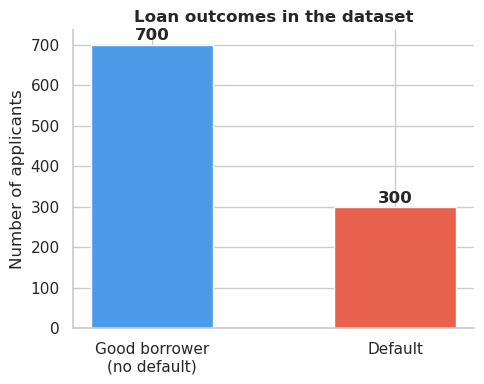

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))

counts = df["default"].value_counts()
ax.bar(["Good borrower\n(no default)", "Default"],
       counts.values,
       color=["#4C9BE8", "#E8614C"],
       width=0.5)

for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha="center", fontweight="bold")

ax.set_title("Loan outcomes in the dataset", fontweight="bold")
ax.set_ylabel("Number of applicants")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

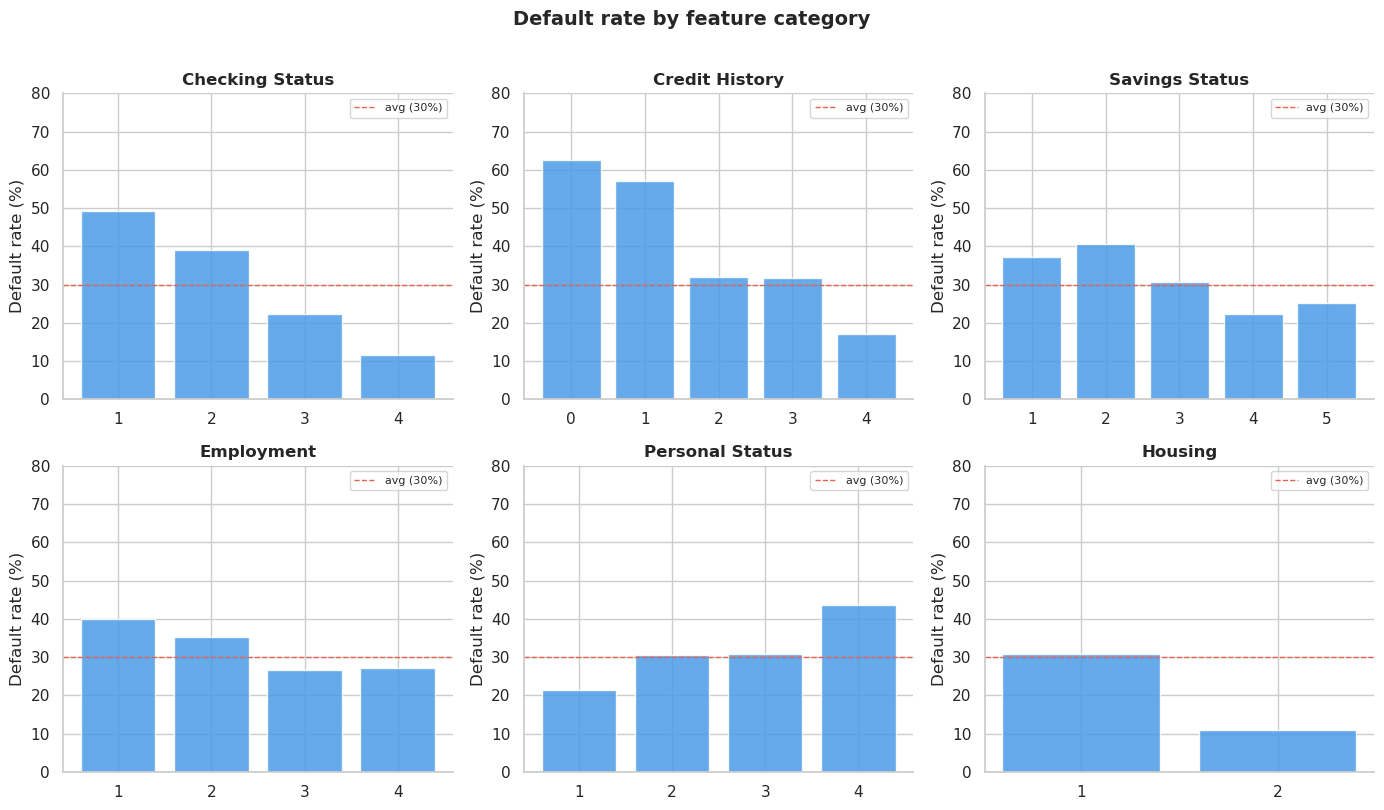

Saved: default_rate_by_feature.png


In [6]:
# --- chart 1: default rate by feature ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

features = ["checking_status", "credit_history", "savings_status",
            "employment", "personal_status", "housing"]

for i, feat in enumerate(features):
    default_rate = df.groupby(feat)["default"].mean() * 100
    axes[i].bar(default_rate.index.astype(str), default_rate.values,
                color="#4C9BE8", alpha=0.85)
    axes[i].set_title(feat.replace("_", " ").title(), fontweight="bold")
    axes[i].set_ylabel("Default rate (%)")
    axes[i].set_ylim(0, 80)
    axes[i].spines[["top", "right"]].set_visible(False)
    axes[i].axhline(30, color="#E8614C", linestyle="--", linewidth=1, label="avg (30%)")
    axes[i].legend(fontsize=8)

plt.suptitle("Default rate by feature category", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("default_rate_by_feature.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: default_rate_by_feature.png")

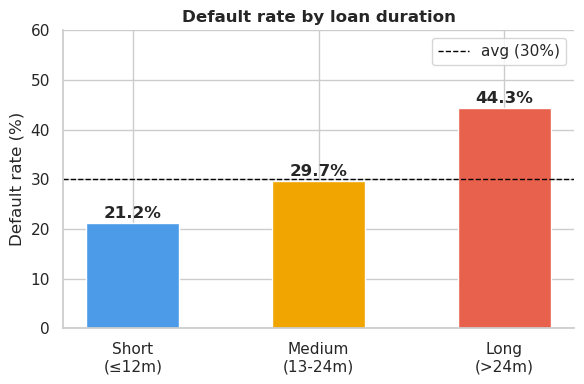

Saved: default_rate_by_duration.png


In [7]:
# --- chart 2 :default rate by loan duration (line chart) ---

df["duration_band"] = pd.cut(df["duration"],
                              bins=[0, 12, 24, 72],
                              labels=["Short\n(≤12m)", "Medium\n(13-24m)", "Long\n(>24m)"])

duration_default = df.groupby("duration_band", observed=True)["default"].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(duration_default.index.astype(str), duration_default.values,
       color=["#4C9BE8", "#F0A500", "#E8614C"], width=0.5)

for i, v in enumerate(duration_default.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

ax.axhline(30, color="black", linestyle="--", linewidth=1, label="avg (30%)")
ax.set_title("Default rate by loan duration", fontweight="bold")
ax.set_ylabel("Default rate (%)")
ax.set_ylim(0, 60)
ax.spines[["top", "right"]].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig("default_rate_by_duration.png", dpi=150)
plt.show()
print("Saved: default_rate_by_duration.png")

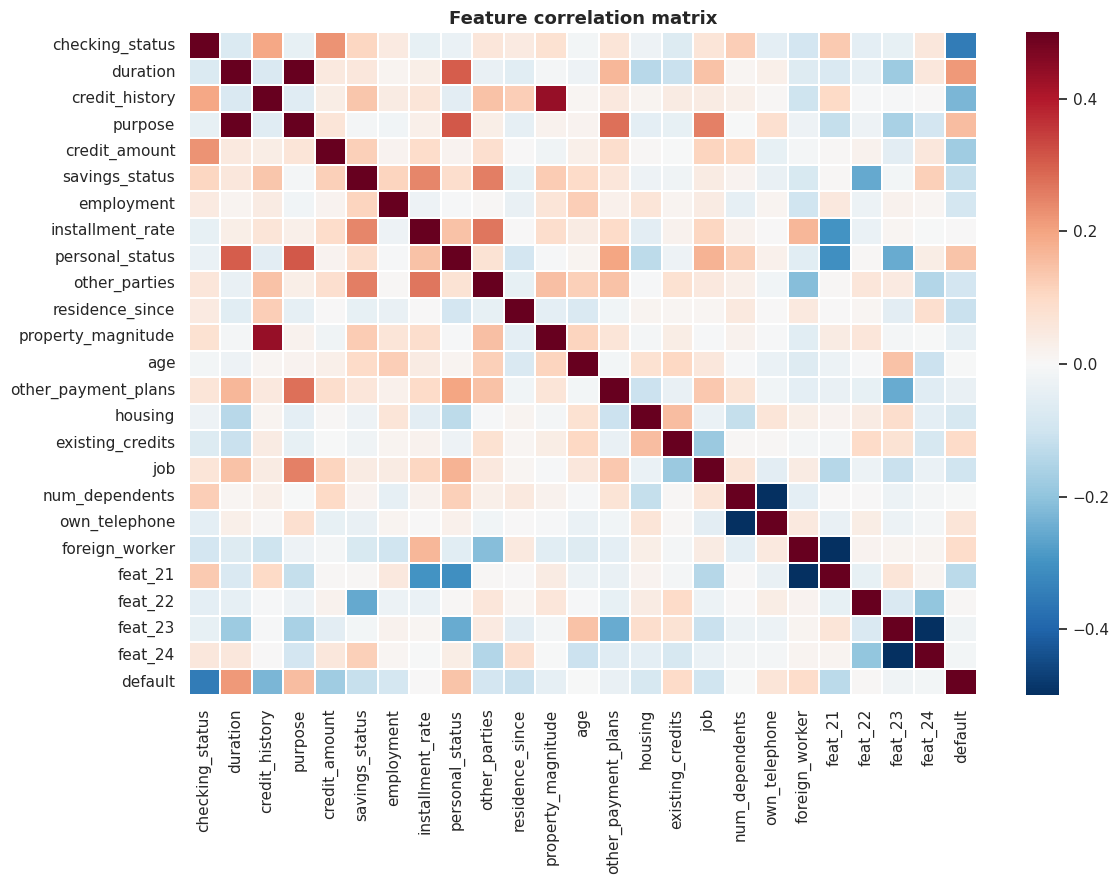

Saved: correlation_heatmap.png


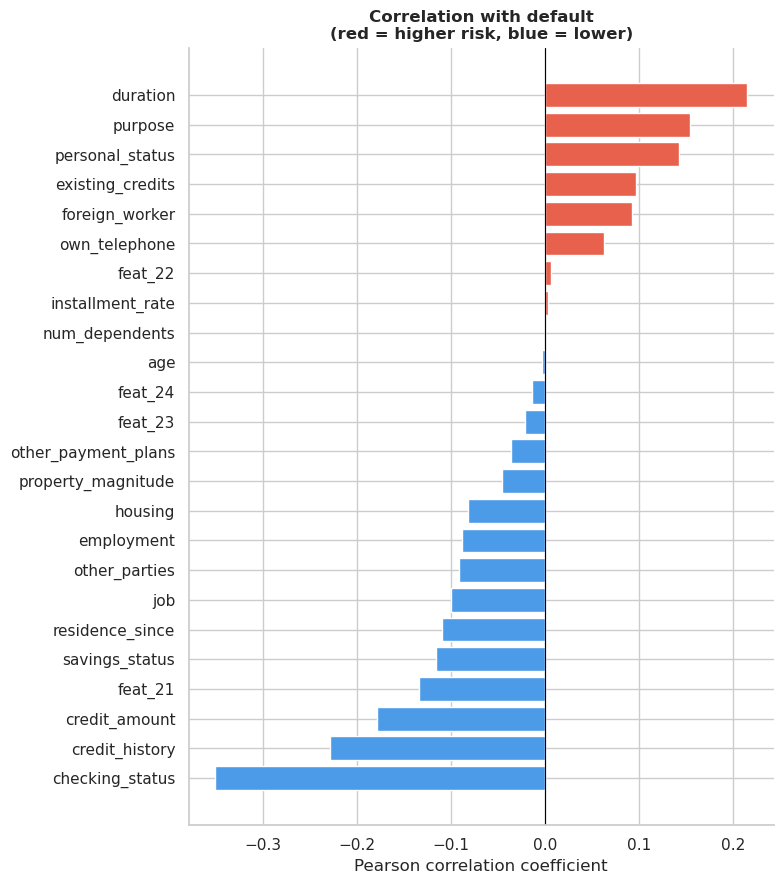

Saved: feature_correlation_with_default.png


In [8]:
# --- correlation heatmap ---
# dark red = strong positive correlation with default
# dark blue = strong negative correlation

df_corr = df.drop(columns=["duration_band"], errors="ignore")
corr = df_corr.corr()

# heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=False, cmap="RdBu_r", center=0,
            vmin=-0.5, vmax=0.5, linewidths=0.3, linecolor="white")
plt.title("Feature correlation matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()
print("Saved: correlation_heatmap.png")

# correlation with default
default_corr = corr["default"].drop("default").sort_values()
colors = ["#E8614C" if v > 0 else "#4C9BE8" for v in default_corr.values]

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(default_corr.index, default_corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation with default\n(red = higher risk, blue = lower)",
             fontweight="bold")
ax.set_xlabel("Pearson correlation coefficient")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("feature_correlation_with_default.png", dpi=150)
plt.show()
print("Saved: feature_correlation_with_default.png")

In [9]:
print("=== Top 5 features INCREASING default risk ===")
for feat, val in corr["default"].drop("default").sort_values(ascending=False).head(5).items():
    print(f"  {feat:<25} +{val:.3f}")

print("\n=== Top 5 features DECREASING default risk ===")
for feat, val in corr["default"].drop("default").sort_values().head(5).items():
    print(f"  {feat:<25} {val:.3f}")

=== Top 5 features INCREASING default risk ===
  duration                  +0.215
  purpose                   +0.154
  personal_status           +0.143
  existing_credits          +0.097
  foreign_worker            +0.093

=== Top 5 features DECREASING default risk ===
  checking_status           -0.351
  credit_history            -0.229
  credit_amount             -0.179
  feat_21                   -0.135
  savings_status            -0.116


In [11]:
# ── train/test split ──────────────────────────────────────

from sklearn.model_selection import train_test_split

df_corr = df.drop(columns=["duration_band"], errors="ignore")
corr = df_corr.corr()
X = df.drop(columns=["default", "duration_band"], errors="ignore")
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% held out for testing
    random_state=42,     # makes results reproducible
    stratify=y           # keeps the 70/30 ratio in both splits
)

print(f"Training set:  {X_train.shape[0]} applicants")
print(f"Test set:      {X_test.shape[0]} applicants")
print(f"\nDefault rate in training set: {y_train.mean():.1%}")
print(f"Default rate in test set:     {y_test.mean():.1%}")

Training set:  800 applicants
Test set:      200 applicants

Default rate in training set: 30.0%
Default rate in test set:     30.0%


In [12]:
# ── SMOTE ─────────────────────────────────────────────────

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE - Good: {(y_train==0).sum()}, Default: {(y_train==1).sum()}")
print(f"After SMOTE  - Good: {(y_train_sm==0).sum()}, Default: {(y_train_sm==1).sum()}")

Before SMOTE - Good: 560, Default: 240
After SMOTE  - Good: 560, Default: 560


In [13]:
# ── logistic regression ───────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

lr_model.fit(X_train_sm, y_train_sm)
print("Logistic regression trained")

Logistic regression trained


In [14]:
# ── XGBoost ───────────────────────────────────────────────

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)

xgb_model.fit(X_train_sm, y_train_sm)
print("XGBoost trained")

XGBoost trained


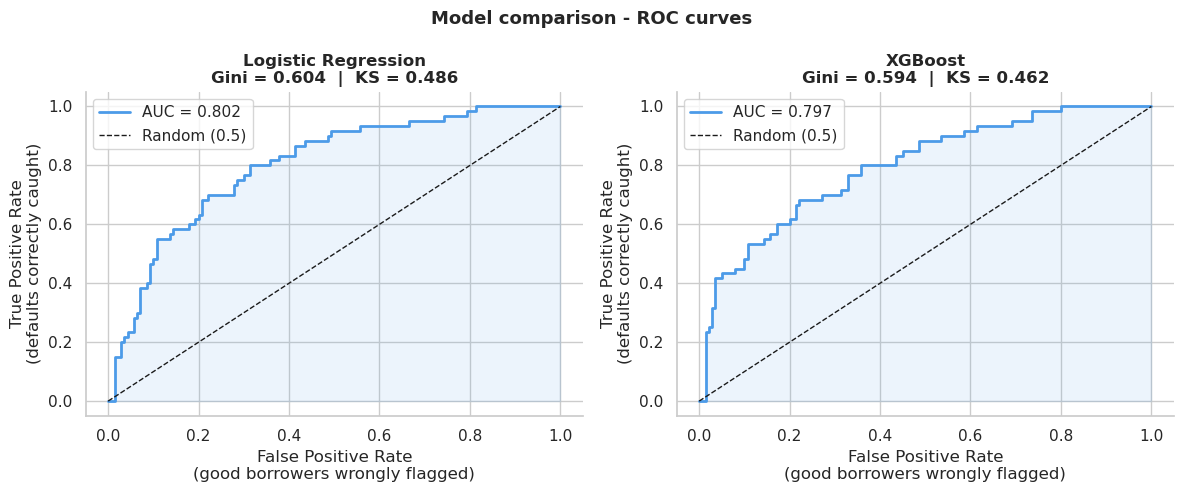


=== Model Performance Summary ===
Metric      Logistic Reg      XGBoost
--------------------------------------
AUC                0.802        0.797
Gini               0.604        0.594
KS                 0.486        0.462


In [15]:
# ── model comparison ──────────────────────────────────────
from sklearn.metrics import roc_auc_score, roc_curve

models = {
    "Logistic Regression": lr_model,
    "XGBoost":             xgb_model
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
results = {}

for ax, (name, model) in zip(axes, models.items()):
    y_prob = model.predict_proba(X_test)[:, 1]

    auc  = roc_auc_score(y_test, y_prob)
    gini = 2 * auc - 1
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ks   = (tpr - fpr).max()

    results[name] = {"AUC": auc, "Gini": gini, "KS": ks}

    ax.plot(fpr, tpr, color="#4C9BE8", linewidth=2, label=f"AUC = {auc:.3f}")
    ax.plot([0,1],[0,1], "k--", linewidth=1, label="Random (0.5)")
    ax.fill_between(fpr, tpr, alpha=0.1, color="#4C9BE8")
    ax.set_title(f"{name}\nGini = {gini:.3f}  |  KS = {ks:.3f}", fontweight="bold")
    ax.set_xlabel("False Positive Rate\n(good borrowers wrongly flagged)")
    ax.set_ylabel("True Positive Rate\n(defaults correctly caught)")
    ax.legend()
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Model comparison - ROC curves", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("model_comparison_roc.png", dpi=150)
plt.show()

print("\n=== Model Performance Summary ===")
print(f"{'Metric':<8} {'Logistic Reg':>15} {'XGBoost':>12}")
print("-" * 38)
for metric in ["AUC", "Gini", "KS"]:
    lr_val  = results["Logistic Regression"][metric]
    xgb_val = results["XGBoost"][metric]
    print(f"{metric:<8} {lr_val:>15.3f} {xgb_val:>12.3f}")

In [16]:
# ── score the test set ────────────────────────────────────
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

scores = pd.Series((1 - y_prob_lr) * 1000, index=X_test.index)

def assign_band(score):
    if score >= 700:
        return "Low Risk"
    elif score >= 500:
        return "Medium Risk"
    else:
        return "High Risk"

scorecard_df = X_test.copy()
scorecard_df["actual_default"]  = y_test.values
scorecard_df["pd_score"]        = y_prob_lr.round(3)
scorecard_df["credit_score"]    = scores.round(0).astype(int)
scorecard_df["risk_band"]       = scores.apply(assign_band)

print("=== Scorecard output (first 10 applicants) ===")
print(scorecard_df[["checking_status", "duration", "credit_history",
                     "pd_score", "credit_score", "risk_band",
                     "actual_default"]].head(10).to_string())

=== Scorecard output (first 10 applicants) ===
     checking_status  duration  credit_history  pd_score  credit_score    risk_band  actual_default
30                 2        18               2     0.304           696  Medium Risk               0
128                2        12               4     0.138           862     Low Risk               0
289                1        24               3     0.682           318    High Risk               1
216                1        18               0     0.797           203    High Risk               0
966                2        27               4     0.239           761     Low Risk               1
346                2        13               4     0.348           652  Medium Risk               0
537                2        18               4     0.141           859     Low Risk               0
47                 1         6               2     0.080           920     Low Risk               0
112                2        18               2     0.

In [17]:
# ── risk band summary ─────────────────────────────────────

band_summary = scorecard_df.groupby("risk_band").agg(
    applicants    = ("risk_band", "count"),
    avg_pd        = ("pd_score", "mean"),
    avg_score     = ("credit_score", "mean"),
    actual_defaults = ("actual_default", "sum"),
    default_rate  = ("actual_default", "mean")
).round(3)

band_summary = band_summary.reindex(["Low Risk", "Medium Risk", "High Risk"])
print("=== Risk band summary ===")
print(band_summary.to_string())

=== Risk band summary ===
             applicants  avg_pd  avg_score  actual_defaults  default_rate
risk_band                                                                
Low Risk             98   0.127    873.204               11         0.112
Medium Risk          35   0.394    606.086               11         0.314
High Risk            67   0.726    273.985               38         0.567


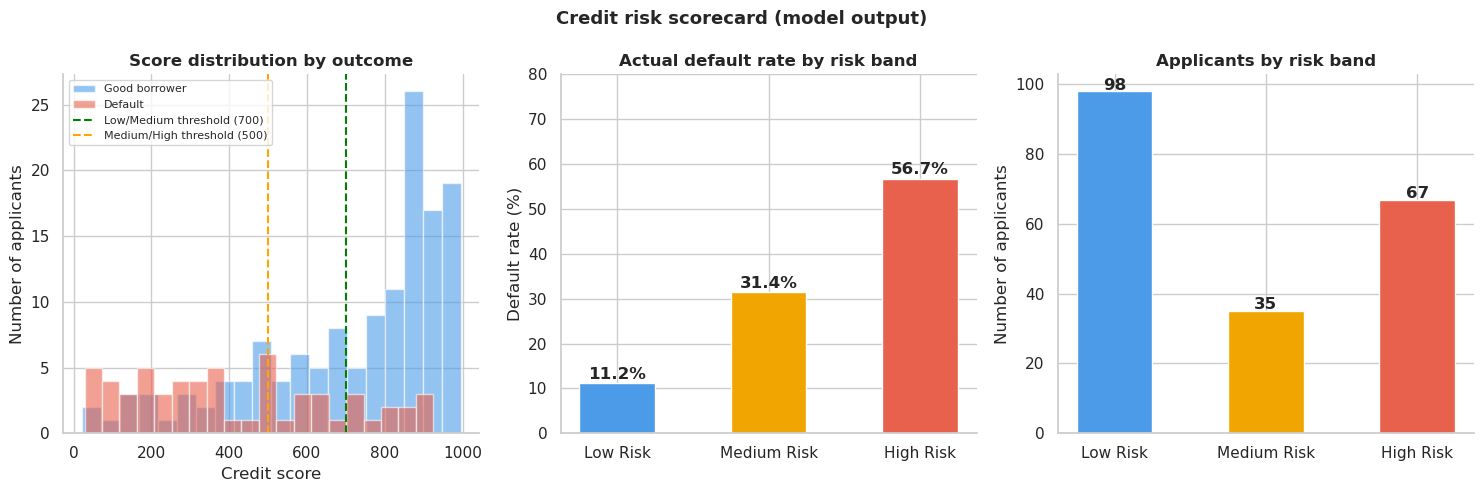

Saved: scorecard_output.png


In [18]:
# ── scorecard visualisation ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# chart 1: score distribution by actual outcome
axes[0].hist(scorecard_df[scorecard_df["actual_default"]==0]["credit_score"],
             bins=20, alpha=0.6, color="#4C9BE8", label="Good borrower")
axes[0].hist(scorecard_df[scorecard_df["actual_default"]==1]["credit_score"],
             bins=20, alpha=0.6, color="#E8614C", label="Default")
axes[0].axvline(700, color="green", linestyle="--", linewidth=1.5, label="Low/Medium threshold (700)")
axes[0].axvline(500, color="orange", linestyle="--", linewidth=1.5, label="Medium/High threshold (500)")
axes[0].set_title("Score distribution by outcome", fontweight="bold")
axes[0].set_xlabel("Credit score")
axes[0].set_ylabel("Number of applicants")
axes[0].legend(fontsize=8)
axes[0].spines[["top","right"]].set_visible(False)

# chart 2: default rate by risk band
band_colors = {"Low Risk": "#4C9BE8", "Medium Risk": "#F0A500", "High Risk": "#E8614C"}
bands = ["Low Risk", "Medium Risk", "High Risk"]
default_rates = [band_summary.loc[b, "default_rate"] * 100 for b in bands]

bars = axes[1].bar(bands, default_rates,
                   color=[band_colors[b] for b in bands],
                   width=0.5)
for bar, rate in zip(bars, default_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f"{rate:.1f}%", ha="center", fontweight="bold")
axes[1].set_title("Actual default rate by risk band", fontweight="bold")
axes[1].set_ylabel("Default rate (%)")
axes[1].set_ylim(0, 80)
axes[1].spines[["top","right"]].set_visible(False)

# chart 3: applicant count by risk band
counts = [band_summary.loc[b, "applicants"] for b in bands]
bars2 = axes[2].bar(bands, counts,
                    color=[band_colors[b] for b in bands],
                    width=0.5)
for bar, count in zip(bars2, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 str(count), ha="center", fontweight="bold")
axes[2].set_title("Applicants by risk band", fontweight="bold")
axes[2].set_ylabel("Number of applicants")
axes[2].spines[["top","right"]].set_visible(False)

plt.suptitle("Credit risk scorecard (model output)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("scorecard_output.png", dpi=150)
plt.show()
print("Saved: scorecard_output.png")

In [19]:
# ── final validation summary ──────────────────────────────

auc  = roc_auc_score(y_test, y_prob_lr)
gini = 2 * auc - 1
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
ks   = (tpr - fpr).max()

print("=" * 45)
print("   CREDIT RISK SCORECARD: VALIDATION REPORT")
print("=" * 45)
print(f"  Model:           Logistic Regression")
print(f"  Dataset:         German Credit (UCI)")
print(f"  Test set size:   {len(y_test)} applicants")
print()
print(f"  AUC:             {auc:.3f}")
print(f"  Gini:            {gini:.3f}  (benchmark: > 0.40)")
print(f"  KS Statistic:    {ks:.3f}  (benchmark: > 0.40)")
print()
print("  Risk band breakdown:")
for band in ["Low Risk", "Medium Risk", "High Risk"]:
    row = band_summary.loc[band]
    print(f"    {band:<12}  {int(row['applicants']):>3} applicants  "
          f"avg score {row['avg_score']:.0f}  "
          f"default rate {row['default_rate']:.1%}")
print("=" * 45)

   CREDIT RISK SCORECARD: VALIDATION REPORT
  Model:           Logistic Regression
  Dataset:         German Credit (UCI)
  Test set size:   200 applicants

  AUC:             0.802
  Gini:            0.604  (benchmark: > 0.40)
  KS Statistic:    0.486  (benchmark: > 0.40)

  Risk band breakdown:
    Low Risk       98 applicants  avg score 873  default rate 11.2%
    Medium Risk    35 applicants  avg score 606  default rate 31.4%
    High Risk      67 applicants  avg score 274  default rate 56.7%


In [20]:
# ── overfitting check ─────────────────────────────────────
y_prob_train = lr_model.predict_proba(X_train_sm)[:, 1]
y_prob_test  = lr_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train_sm, y_prob_train)
test_auc  = roc_auc_score(y_test, y_prob_test)

print(f"Training AUC: {train_auc:.3f}")
print(f"Test AUC:     {test_auc:.3f}")
print(f"Gap:          {train_auc - test_auc:.3f}")
print()
if train_auc - test_auc < 0.05:
    print("No overfitting gap under 0.05")
elif train_auc - test_auc < 0.10:
    print("Mild overfitting acceptable for this dataset size")
else:
    print("Overfitting model is memorising training data")

Training AUC: 0.886
Test AUC:     0.802
Gap:          0.084

Mild overfitting acceptable for this dataset size
